# RB Data Analysis

## Data processing and Fitting

In [2]:
import ast
import os
import re

# This cell only reads from the raw-data folder. It does not modify any raw files.
directory_path = r"Z:\\Lab Data\\Qudit_RB\\Raw_data_PD"

# Set these filters for the RB run you want to load.
dimension = 2
init_state = [0, 3, 0]
LT_comp = True
n_sets = 10
timestamp_filter = ["20260311_2019"]  # Use a list so interrupted runs can span multiple timestamps.


def normalize_init_state(init_state_value):
    if isinstance(init_state_value, str):
        init_state_value = ast.literal_eval(init_state_value)
    return [int(value) for value in init_state_value]


def normalize_lt_comp(lt_comp_value):
    if isinstance(lt_comp_value, str):
        text = lt_comp_value.strip().lower()
        if text not in {"true", "false"}:
            raise ValueError("LT_comp must be True, False, 'True', or 'False'.")
        return text == "true"
    return bool(lt_comp_value)


def normalize_timestamp_filter(timestamp_filter_value):
    if timestamp_filter_value is None:
        return None
    if isinstance(timestamp_filter_value, str):
        return [timestamp_filter_value]
    return [str(value) for value in timestamp_filter_value]


def parse_rb_filename(filename):
    pattern = (
        r"^RBExp_Dim(?P<dimension>\d+)_Init(?P<init_state>\[[^\]]+\])_"
        r"NUnits(?P<n_units>\d+)_LTComp_(?P<lt_comp>True|False)_"
        r"NSets(?P<n_sets>\d+)_(?P<date>\d{8})_(?P<time>\d{4})\.txt$"
    )
    match = re.match(pattern, filename)
    if not match:
        return None

    return {
        "dimension": int(match.group("dimension")),
        "init_state": normalize_init_state(match.group("init_state")),
        "n_units": int(match.group("n_units")),
        "lt_comp": match.group("lt_comp") == "True",
        "n_sets": int(match.group("n_sets")),
        "timestamp": f"{match.group('date')}_{match.group('time')}",
    }


def parse_processed_row(row_text):
    x_text, y_text = row_text.split(",", maxsplit=1)
    return float(x_text), float(y_text)


def extract_rb_file_data(file_path):
    with open(file_path, "r") as file:
        lines = [line.strip() for line in file.readlines() if line.strip()]

    if len(lines) < 20:
        raise ValueError(
            f"Unexpected file format in {os.path.basename(file_path)}: "
            f"expected at least 20 non-empty lines, found {len(lines)}."
        )

    processed_xy_pairs = [parse_processed_row(line) for line in lines[:10]]
    processed_x_values = [x for x, _ in processed_xy_pairs]
    processed_y_values = [y for _, y in processed_xy_pairs]
    payload_rows = [ast.literal_eval(line) for line in lines[10:]]

    return {
        "processed_xy_pairs": processed_xy_pairs,
        "processed_x_values": processed_x_values,
        "processed_y_values": processed_y_values,
        "ignored_row_1": payload_rows[0],
        "ignored_row_2": payload_rows[1],
        "pi_times_ref": payload_rows[2],
        "pulse_train_template": payload_rows[3],
        "pulse_train": payload_rows[4],
        "corrected_pulse_times": payload_rows[5],
        "coupling_train": payload_rows[6],
        "angle_train": payload_rows[7],
        "phase_train": payload_rows[8],
        "raw_data_file_path": payload_rows[-1],
    }


def load_rb_dataset(directory, dimension, init_state, LT_comp, n_sets, timestamp_filter=None):
    init_state = normalize_init_state(init_state)
    LT_comp = normalize_lt_comp(LT_comp)
    timestamp_filter = normalize_timestamp_filter(timestamp_filter)

    if not os.path.isdir(directory):
        raise FileNotFoundError(f"Directory not found: {directory}")

    data_dict = {}
    candidate_files = []

    for filename in sorted(os.listdir(directory)):
        metadata = parse_rb_filename(filename)
        if metadata is None:
            continue

        if metadata["dimension"] == int(dimension) and metadata["init_state"] == init_state:
            candidate_files.append(filename)

        if metadata["dimension"] != int(dimension):
            continue
        if metadata["init_state"] != init_state:
            continue
        if metadata["lt_comp"] != LT_comp:
            continue
        if metadata["n_sets"] != int(n_sets):
            continue
        if timestamp_filter is not None:
            if not any(metadata["timestamp"].startswith(filter_value) for filter_value in timestamp_filter):
                continue

        file_path = os.path.join(directory, filename)
        n_units = metadata["n_units"]
        file_data = extract_rb_file_data(file_path)

        if n_units not in data_dict:
            data_dict[n_units] = {
                "dimension": metadata["dimension"],
                "init_state": metadata["init_state"],
                "LT_comp": metadata["lt_comp"],
                "n_sets": metadata["n_sets"],
                "n_units": metadata["n_units"],
                "file_name": filename,
                "file_path": file_path,
                "timestamp": metadata["timestamp"],
                "file_names": [filename],
                "file_paths": [file_path],
                "timestamps": [metadata["timestamp"]],
                **file_data,
            }
            continue

        existing_entry = data_dict[n_units]
        existing_entry["file_names"].append(filename)
        existing_entry["file_paths"].append(file_path)
        existing_entry["timestamps"].append(metadata["timestamp"])
        existing_entry["processed_xy_pairs"].extend(file_data["processed_xy_pairs"])
        existing_entry["processed_x_values"].extend(file_data["processed_x_values"])
        existing_entry["processed_y_values"].extend(file_data["processed_y_values"])
        existing_entry["pulse_train"].extend(file_data["pulse_train"])
        existing_entry["corrected_pulse_times"].extend(file_data["corrected_pulse_times"])
        existing_entry["coupling_train"].extend(file_data["coupling_train"])
        existing_entry["angle_train"].extend(file_data["angle_train"])
        existing_entry["phase_train"].extend(file_data["phase_train"])
        existing_entry["raw_data_file_path"].extend(file_data["raw_data_file_path"])

    if not data_dict:
        candidate_preview = "\n".join(candidate_files[:15]) if candidate_files else "No RBExp files with this dimension/init_state were found."
        raise FileNotFoundError(
            "No matching RB files were found.\n"
            f"directory={directory}\n"
            f"dimension={dimension}, init_state={init_state}, LT_comp={LT_comp}, n_sets={n_sets}, timestamp_filter={timestamp_filter}\n\n"
            "Candidate files with the same dimension/init_state:\n"
            f"{candidate_preview}"
        )

    return dict(sorted(data_dict.items()))


data_dict = load_rb_dataset(
    directory=directory_path,
    dimension=dimension,
    init_state=init_state,
    LT_comp=LT_comp,
    n_sets=n_sets,
    timestamp_filter=timestamp_filter,
)

available_n_units = list(data_dict)
print(f"Loaded NUnits: {available_n_units}")
# data_dict


Loaded NUnits: [1, 2, 3, 4, 6, 8, 10, 12, 14, 16, 20, 26, 34, 50, 65, 85, 120, 150]


In [3]:
import json
import numpy as np

# Set this based on which column should be treated as the ket population.
ket_1_first = False


def get_shelving_threshold(counts):
    data_sorted = np.sort(counts, axis=None)

    if len(data_sorted) > 4000:
        data_sorted = data_sorted[2000:-2000]
    if len(data_sorted) > 2000:
        step = round(data_sorted.size / (len(counts) * 0.0250167))
        step = max(step, 1)
        data_sorted = data_sorted[0:-1:step]

    data_sorted_diff = data_sorted[1:-1] - data_sorted[0:-2]
    data_diff_max = max(data_sorted_diff)
    data_diff_maxind = np.argmax(data_sorted_diff)
    threshold = data_diff_max / 2 + data_sorted[data_diff_maxind]

    hist_counts, bin_edges = np.histogram(counts, bins=range(4, 31))
    min_bin_index = np.argmin(hist_counts)
    threshold = bin_edges[min_bin_index] + 0.5

    if threshold < 2 or threshold > 20:
        threshold = 11

    return threshold, data_sorted


def find_binomial_errors(num_sd, full_data_array, exp_num):
    upper_error = ((full_data_array + (num_sd**2 / (2 * exp_num))) /
                   (1 + (num_sd**2 / exp_num))) + np.sqrt(
                       ((full_data_array * (1 - full_data_array) * num_sd**2) / exp_num) +
                       (num_sd**4 / (4 * exp_num**2))
                   ) / (1 + (num_sd**2 / exp_num))

    lower_error = ((full_data_array + (num_sd**2 / (2 * exp_num))) /
                   (1 + (num_sd**2 / exp_num))) - np.sqrt(
                       ((full_data_array * (1 - full_data_array) * num_sd**2) / exp_num) +
                       (num_sd**4 / (4 * exp_num**2))
                   ) / (1 + (num_sd**2 / exp_num))

    return lower_error, upper_error


def process_raw_data_files(raw_data_filepaths, ket_1_first=False):
    all_counts = []

    for file_path in raw_data_filepaths:
        with open(file_path, "r") as file:
            for line in file:
                data = json.loads(line)
                all_counts.append(data[0]["0"])

    hist_data = np.array(all_counts)
    flat_hist_data = hist_data.flatten()
    threshold, _ = get_shelving_threshold(flat_hist_data)

    arrays_3d = []
    for file_path in raw_data_filepaths:
        arrays = []
        with open(file_path, "r") as file:
            for line in file:
                data = json.loads(line)
                arrays.append(data[0]["0"][:])

        if len(arrays) == 0:
            arrays = list(np.full((100, 3), 40))
        arrays_3d.append(arrays)

    bool_array = np.array(arrays_3d) > threshold
    result_matrix = np.full(bool_array.shape, False, dtype=bool)

    if bool_array.shape[2] < 3:
        result_matrix = np.full(bool_array.shape + np.array([0, 0, 1]), False, dtype=bool)

    for matrix_index in range(bool_array.shape[0]):
        for row_index in range(bool_array.shape[1]):
            data_bool = bool_array[matrix_index, row_index, :]
            if data_bool[0] is False or data_bool[0] == False:
                if data_bool[1] is True or data_bool[1] == True:
                    result_matrix[matrix_index, row_index, 1] = True
                if data_bool[1] is False or data_bool[1] == False:
                    result_matrix[matrix_index, row_index, 2] = True

    filtered_data_array = []
    percentage_data_used = []
    num_points = bool_array.shape[0]

    for i in range(num_points):
        data = result_matrix[i]
        rows_with_any_true = data.any(axis=1)
        filtered_data = data[rows_with_any_true]
        filtered_data_array.append(filtered_data)
        percentage_data_used.append(filtered_data.shape[0] / data.shape[0])

    ket_data = []
    exp_num_list = []
    ket_index = 2 if ket_1_first else 1

    for filtered_data in filtered_data_array:
        ket_data.append(np.mean(filtered_data, axis=0)[ket_index])
        exp_num_list.append(len(filtered_data))

    ket_data = np.array(ket_data, dtype=float)
    exp_num_array = np.array(exp_num_list, dtype=float)
    lower_error, upper_error = find_binomial_errors(1, ket_data, exp_num_array)

    return {
        "threshold": float(threshold),
        "ket_data": ket_data.tolist(),
        "lower_error": np.abs(ket_data - lower_error).tolist(),
        "upper_error": np.abs(upper_error - ket_data).tolist(),
        "exp_num_list": exp_num_list,
        "percentage_data_used": percentage_data_used,
    }


def analyze_rb_data_dict(data_dict, ket_1_first=False):
    analyzed_data_dict = {}

    for n_units, entry in data_dict.items():
        analysis_result = process_raw_data_files(entry["raw_data_file_path"], ket_1_first=ket_1_first)
        analyzed_data_dict[n_units] = {
            **entry,
            **analysis_result,
        }

    return analyzed_data_dict


analyzed_data_dict = analyze_rb_data_dict(data_dict, ket_1_first=ket_1_first)

for n_units, entry in analyzed_data_dict.items():
    print(f"NUnits {n_units}: ket_data length = {len(entry['ket_data'])}, threshold = {entry['threshold']:.2f}")
    print('Ket data = ', entry['ket_data'])

# If you want the original dictionary name to include the analysis results, uncomment the next line.
# data_dict = analyzed_data_dict


NUnits 1: ket_data length = 10, threshold = 10.50
Ket data =  [1.0, 0.99, 0.9690721649484536, 0.9894736842105263, 1.0, 0.9791666666666666, 1.0, 0.9897959183673469, 0.9897959183673469, 0.9897959183673469]
NUnits 2: ket_data length = 10, threshold = 10.50
Ket data =  [1.0, 0.99, 1.0, 0.98989898989899, 0.98989898989899, 0.9897959183673469, 1.0, 1.0, 0.9897959183673469, 1.0]
NUnits 3: ket_data length = 10, threshold = 9.50
Ket data =  [0.9896907216494846, 1.0, 0.98989898989899, 0.98989898989899, 1.0, 0.968421052631579, 1.0, 0.9897959183673469, 0.98989898989899, 0.98989898989899]
NUnits 4: ket_data length = 10, threshold = 9.50
Ket data =  [1.0, 1.0, 0.9897959183673469, 0.98, 1.0, 0.98989898989899, 1.0, 1.0, 0.9789473684210527, 0.9797979797979798]
NUnits 6: ket_data length = 10, threshold = 10.50
Ket data =  [0.98989898989899, 0.9897959183673469, 0.9897959183673469, 1.0, 0.99, 0.98, 1.0, 0.9897959183673469, 1.0, 0.9896907216494846]
NUnits 8: ket_data length = 10, threshold = 8.50
Ket data =

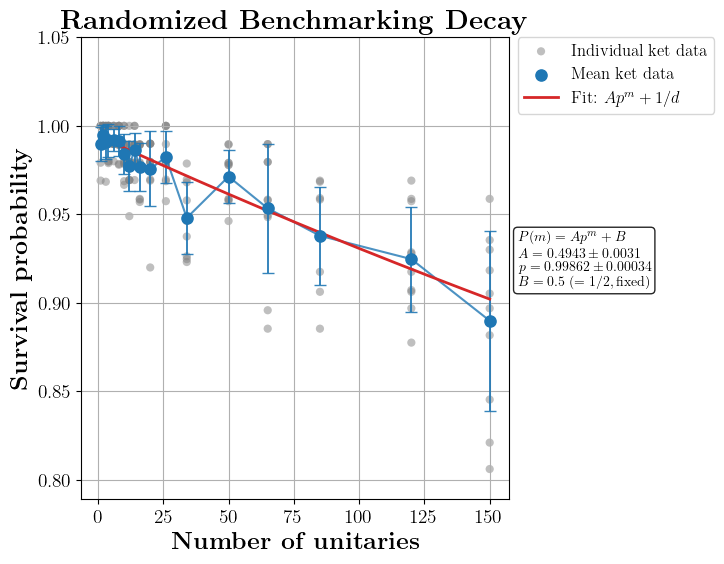

{'A': 0.4943014771311023, 'p': 0.9986249677441564, 'B': 0.5}


In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from scipy.optimize import curve_fit

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True
rcParams['figure.figsize'] = (8, 6)


def rb_decay_model(m, A, p, B):
    return A * (p ** m) + B


def rb_decay_model_fixed_b(m, A, p, fixed_b):
    return rb_decay_model(m, A, p, fixed_b)


def format_rb_axes(ax, xlabel_text, ylabel_text, title_text, xlabel_unit=None, ylabel_unit=None):
    def _build_label(text, unit=None):
        latex_text = text.replace(' ', r'\ ')
        if unit is None:
            return rf'\boldmath$\textbf{{{latex_text}}}$'
        return rf'\boldmath$\textbf{{{latex_text}}}\quad [{unit}]$'

    ax.set_xlabel(_build_label(xlabel_text, xlabel_unit), fontsize=18)
    ax.set_ylabel(_build_label(ylabel_text, ylabel_unit), fontsize=18)
    ax.set_title(rf'\textbf{{{title_text}}}', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid()


def infer_rb_dimension(analyzed_data_dict, dimension_value=None):
    if dimension_value is not None:
        return int(dimension_value)

    first_entry = next(iter(analyzed_data_dict.values()))
    if "dimension" in first_entry:
        return int(first_entry["dimension"])
    if "dimension" in globals():
        return int(globals()["dimension"])

    raise ValueError("Could not infer RB dimension. Pass dimension_value explicitly or store 'dimension' in analyzed_data_dict entries.")


def get_fixed_b_from_dimension(dimension_value):
    dimension_value = int(dimension_value)
    if dimension_value <= 0:
        raise ValueError("RB dimension must be positive.")
    return 1.0 / float(dimension_value)


def get_fit_uncertainties(fit_covariance, parameter_names):
    covariance_diagonal = np.diag(fit_covariance)
    covariance_diagonal = np.where(np.isfinite(covariance_diagonal), covariance_diagonal, np.nan)
    covariance_diagonal = np.clip(covariance_diagonal, 0.0, None)
    fit_uncertainties = np.sqrt(covariance_diagonal)
    return {
        name: float(fit_uncertainties[idx])
        for idx, name in enumerate(parameter_names)
    }


def format_value_and_uncertainty(value, uncertainty):
    if not np.isfinite(uncertainty) or uncertainty <= 0:
        return f"{value:.6g}"

    exponent = int(np.floor(np.log10(abs(uncertainty))))
    decimals = int(np.clip(1 - exponent, 0, 8))
    return f"{value:.{decimals}f} \\pm {uncertainty:.{decimals}f}"


def build_fit_annotation_text(fit_params, fit_uncertainties, fixed_b_value, dimension_value, header=None):
    annotation_lines = []
    if header is not None:
        annotation_lines.append(rf"\textbf{{{header}}}")

    annotation_lines.extend([
        r"$P(m) = A p^{m} + B$",
        rf"$A = {format_value_and_uncertainty(fit_params['A'], fit_uncertainties['A'])}$",
        rf"$p = {format_value_and_uncertainty(fit_params['p'], fit_uncertainties['p'])}$",
        rf"$B = {fixed_b_value:.6g}\; (= 1/{int(dimension_value)},\mathrm{{fixed}})$",
    ])
    return "\n".join(annotation_lines)


def configure_right_side_layout(fig, right_edge):
    if len(fig.axes) == 1:
        fig.subplots_adjust(right=right_edge)


def plot_rb_decay(analyzed_data_dict, ax=None, dimension_value=None):
    if not analyzed_data_dict:
        raise ValueError("analyzed_data_dict is empty.")

    dimension_value = infer_rb_dimension(analyzed_data_dict, dimension_value=dimension_value)
    fixed_b = get_fixed_b_from_dimension(dimension_value)

    sorted_items = sorted(analyzed_data_dict.items())
    n_units = np.array([item[0] for item in sorted_items], dtype=float)
    ket_data_lists = [np.array(item[1]["ket_data"], dtype=float) for item in sorted_items]
    mean_ket_data = np.array([np.mean(ket_values) for ket_values in ket_data_lists], dtype=float)
    std_ket_data = np.array([
        np.std(ket_values, ddof=1) if len(ket_values) > 1 else 0.0
        for ket_values in ket_data_lists
    ], dtype=float)
    sem_ket_data = np.array([
        std_ket_data[idx] / np.sqrt(len(ket_values)) if len(ket_values) > 1 else 1e-3
        for idx, ket_values in enumerate(ket_data_lists)
    ], dtype=float)
    sem_ket_data = np.clip(sem_ket_data, 1e-3, None)
    fit_sigma = np.clip(std_ket_data, 1e-3, None)

    if len(n_units) < 3:
        raise ValueError("Need at least 3 NUnits points to fit A * p^m + 1/d.")

    initial_A = float(np.clip(mean_ket_data[0] - fixed_b, 1e-6, 1.5))
    initial_p = 0.995

    fit_params, fit_covariance = curve_fit(
        lambda m, A, p: rb_decay_model_fixed_b(m, A, p, fixed_b),
        n_units,
        mean_ket_data,
        p0=(initial_A, initial_p),
        bounds=([0.0, 0.0], [1.5, 1.0]),
        sigma=fit_sigma,
        absolute_sigma=True,
        maxfev=20000,
    )

    A_fit, p_fit = fit_params
    B_fit = fixed_b
    fit_uncertainties = get_fit_uncertainties(fit_covariance, ["A", "p"])
    fit_uncertainties["B"] = 0.0
    fit_n_units = np.linspace(n_units.min(), n_units.max(), 500)
    fit_curve = rb_decay_model_fixed_b(fit_n_units, A_fit, p_fit, fixed_b)

    created_figure = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
        created_figure = True
    else:
        fig = ax.figure

    configure_right_side_layout(fig, right_edge=0.66)

    gray_label_added = False
    for m_value, ket_values in zip(n_units, ket_data_lists):
        label = "Individual ket data" if not gray_label_added else None
        ax.scatter(
            np.full(len(ket_values), m_value, dtype=float),
            ket_values,
            color="gray",
            alpha=0.5,
            s=35,
            edgecolors="none",
            label=label,
        )
        gray_label_added = True

    ax.plot(n_units, mean_ket_data, color="tab:blue", linewidth=1.5, alpha=0.8)
    ax.errorbar(
        n_units,
        mean_ket_data,
        yerr=std_ket_data,
        fmt="none",
        ecolor="tab:blue",
        elinewidth=1.4,
        capsize=4,
        alpha=0.9,
        zorder=2,
    )
    ax.scatter(n_units, mean_ket_data, color="tab:blue", s=65, zorder=3, label="Mean ket data")
    ax.plot(fit_n_units, fit_curve, color="tab:red", linewidth=2.0, label=r"Fit: $A p^m + 1/d$")

    format_rb_axes(
        ax,
        xlabel_text="Number of unitaries",
        ylabel_text="Survival probability",
        title_text="Randomized Benchmarking Decay",
    )
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0, fontsize=12)

    y_min = min(np.min(mean_ket_data - std_ket_data), np.min(fit_curve)) - 0.05
    y_max = max(np.max(mean_ket_data + std_ket_data), np.max(fit_curve)) + 0.05
    ax.set_ylim(max(0.0, y_min), min(1.05, y_max))

    fit_text = build_fit_annotation_text(
        fit_params={"A": float(A_fit), "p": float(p_fit), "B": float(B_fit)},
        fit_uncertainties=fit_uncertainties,
        fixed_b_value=fixed_b,
        dimension_value=dimension_value,
    )
    ax.text(
        1.02,
        0.58,
        fit_text,
        transform=ax.transAxes,
        fontsize=10,
        va="top",
        ha="left",
        clip_on=False,
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
    )

    if created_figure:
        plt.show()

    return {
        "figure": fig,
        "axis": ax,
        "fit_params": {"A": float(A_fit), "p": float(p_fit), "B": float(B_fit)},
        "fit_covariance": fit_covariance,
        "fit_uncertainties": fit_uncertainties,
        "dimension": int(dimension_value),
        "fixed_b_value": float(fixed_b),
        "n_units": n_units,
        "mean_ket_data": mean_ket_data,
        "std_ket_data": std_ket_data,
        "sem_ket_data": sem_ket_data,
        "fit_sigma": fit_sigma,
    }


rb_plot_result = plot_rb_decay(analyzed_data_dict)
print(rb_plot_result["fit_params"])


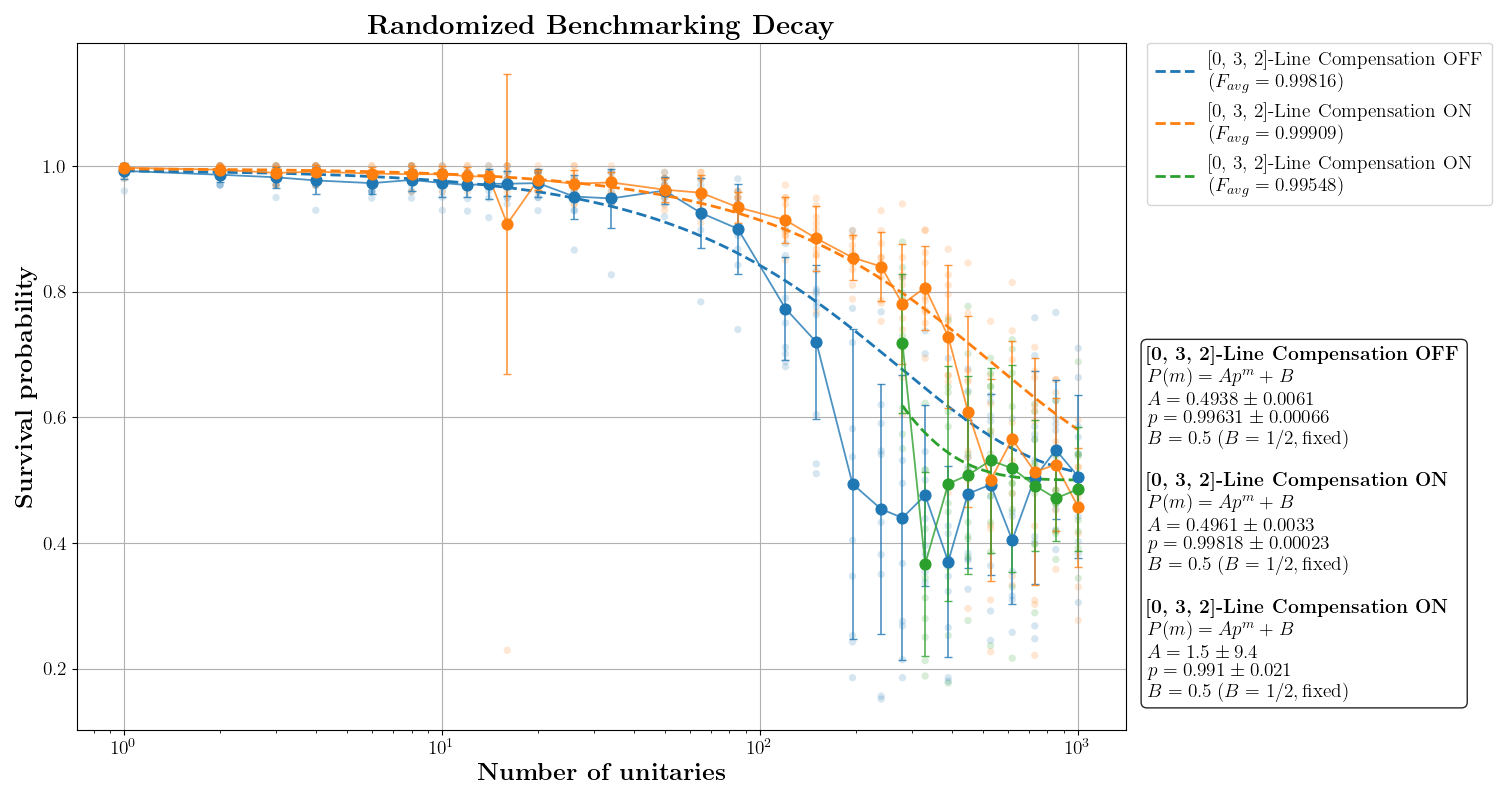

In [53]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from scipy.optimize import curve_fit

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True
rcParams['figure.figsize'] = (15, 8)


def rb_decay_model(m, A, p, B):
    return A * (p ** m) + B


def rb_decay_model_fixed_b(m, A, p, fixed_b):
    return rb_decay_model(m, A, p, fixed_b)


def format_rb_axes(ax, xlabel_text, ylabel_text, title_text, xlabel_unit=None, ylabel_unit=None):
    def _build_label(text, unit=None):
        latex_text = text.replace(' ', r'\ ')
        if unit is None:
            return rf'\boldmath$\textbf{{{latex_text}}}$'
        return rf'\boldmath$\textbf{{{latex_text}}}\quad [{unit}]$'

    ax.set_xlabel(_build_label(xlabel_text, xlabel_unit), fontsize=18)
    ax.set_ylabel(_build_label(ylabel_text, ylabel_unit), fontsize=18)
    ax.set_title(rf'\textbf{{{title_text}}}', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid()


def get_fixed_b_from_dimension(dimension_value):
    dimension_value = int(dimension_value)
    if dimension_value <= 0:
        raise ValueError("RB dimension must be positive.")
    return 1.0 / float(dimension_value)


def get_fit_uncertainties(fit_covariance, parameter_names):
    covariance_diagonal = np.diag(fit_covariance)
    covariance_diagonal = np.where(np.isfinite(covariance_diagonal), covariance_diagonal, np.nan)
    covariance_diagonal = np.clip(covariance_diagonal, 0.0, None)
    fit_uncertainties = np.sqrt(covariance_diagonal)
    return {
        name: float(fit_uncertainties[idx])
        for idx, name in enumerate(parameter_names)
    }


def format_value_and_uncertainty(value, uncertainty):
    if not np.isfinite(uncertainty) or uncertainty <= 0:
        return f"{value:.6g}"

    exponent = int(np.floor(np.log10(abs(uncertainty))))
    decimals = int(np.clip(1 - exponent, 0, 8))
    return f"{value:.{decimals}f} \\pm {uncertainty:.{decimals}f}"


def build_fit_annotation_text(fit_params, fit_uncertainties, fixed_b_value, dimension_value, header=None):
    annotation_lines = []
    if header is not None:
        annotation_lines.append(rf"\textbf{{{header}}}")

    annotation_lines.extend([
        r"$P(m) = A p^{m} + B$",
        rf"$A = {format_value_and_uncertainty(fit_params['A'], fit_uncertainties['A'])}$",
        rf"$p = {format_value_and_uncertainty(fit_params['p'], fit_uncertainties['p'])}$",
        rf"$B = {fixed_b_value:.6g}\; (B = 1/{int(dimension_value)},\mathrm{{fixed}})$",
    ])
    return "\n".join(annotation_lines)


def configure_right_side_layout(fig, right_edge):
    if len(fig.axes) == 1:
        fig.subplots_adjust(right=right_edge)


def compute_average_rb_error_rate(p_value, dimension_value):
    dimension_value = float(dimension_value)
    return (dimension_value - 1.0) * (1.0 - float(p_value)) / dimension_value


def format_error_rate_label(error_rate):
    if np.isclose(error_rate, 0.0):
        return "0"

    exponent = int(np.floor(np.log10(abs(error_rate))))
    if -2 <= exponent <= 2:
        return f"{error_rate:.4f}"

    mantissa = error_rate / (10 ** exponent)
    return rf"{mantissa:.2f} \times 10^{{{exponent}}}"


def _is_multi_value(value, field_name):
    if isinstance(value, np.ndarray):
        value = value.tolist()

    if isinstance(value, (str, bytes)):
        return False

    if field_name == "init_state":
        return isinstance(value, (list, tuple)) and len(value) > 0 and isinstance(value[0], (list, tuple, np.ndarray))

    if field_name == "timestamp_filter":
        return isinstance(value, (list, tuple)) and len(value) > 0 and isinstance(value[0], (list, tuple, np.ndarray))

    return isinstance(value, (list, tuple, np.ndarray))


def _broadcast_value(value, field_name, num_configs):
    if _is_multi_value(value, field_name):
        value_list = list(value)
        if len(value_list) not in {1, num_configs}:
            raise ValueError(
                f"Field '{field_name}' has length {len(value_list)}, expected 1 or {num_configs}."
            )
        if len(value_list) == 1 and num_configs > 1:
            return value_list * num_configs
        return value_list

    return [value] * num_configs


def build_rb_pipeline_configs(
    dimension,
    init_state,
    LT_comp,
    n_sets,
    timestamp_filter,
    labels=None,
):
    fields = {
        "dimension": dimension,
        "init_state": init_state,
        "LT_comp": LT_comp,
        "n_sets": n_sets,
        "timestamp_filter": timestamp_filter,
    }

    multi_lengths = [
        len(list(value))
        for field_name, value in fields.items()
        if _is_multi_value(value, field_name)
    ]
    num_configs = max(multi_lengths) if multi_lengths else 1

    dimensions = _broadcast_value(dimension, "dimension", num_configs)
    init_states = _broadcast_value(init_state, "init_state", num_configs)
    lt_comp_values = _broadcast_value(LT_comp, "LT_comp", num_configs)
    n_sets_values = _broadcast_value(n_sets, "n_sets", num_configs)
    timestamp_filters = _broadcast_value(timestamp_filter, "timestamp_filter", num_configs)

    if labels is None:
        labels = [None] * num_configs
    else:
        labels = _broadcast_value(labels, "labels", num_configs)

    configs = []
    for idx in range(num_configs):
        config = {
            "dimension": int(dimensions[idx]),
            "init_state": normalize_init_state(init_states[idx]),
            "LT_comp": normalize_lt_comp(lt_comp_values[idx]),
            "n_sets": int(n_sets_values[idx]),
            "timestamp_filter": normalize_timestamp_filter(timestamp_filters[idx]),
        }

        label = labels[idx]
        if label is None:
            label = (
                f"Dim{config['dimension']} Init{config['init_state']} "
                f"LT{config['LT_comp']} NSets{config['n_sets']} {config['timestamp_filter']}"
            )

        configs.append({"config": config, "label": str(label)})

    return configs


def fit_rb_decay_from_analyzed_data(analyzed_data_dict, dimension_value):
    if not analyzed_data_dict:
        raise ValueError("analyzed_data_dict is empty.")

    dimension_value = int(dimension_value)
    fixed_b = get_fixed_b_from_dimension(dimension_value)

    sorted_items = sorted(analyzed_data_dict.items())
    n_units = np.array([item[0] for item in sorted_items], dtype=float)
    ket_data_lists = [np.array(item[1]["ket_data"], dtype=float) for item in sorted_items]
    mean_ket_data = np.array([np.mean(ket_values) for ket_values in ket_data_lists], dtype=float)
    std_ket_data = np.array([
        np.std(ket_values, ddof=1) if len(ket_values) > 1 else 0.0
        for ket_values in ket_data_lists
    ], dtype=float)
    sem_ket_data = np.array([
        std_ket_data[idx] / np.sqrt(len(ket_values)) if len(ket_values) > 1 else 1e-3
        for idx, ket_values in enumerate(ket_data_lists)
    ], dtype=float)
    sem_ket_data = np.clip(sem_ket_data, 1e-3, None)
    fit_sigma = np.clip(std_ket_data, 1e-3, None)

    if len(n_units) < 3:
        raise ValueError("Need at least 3 NUnits points to fit A * p^m + 1/d.")

    initial_A = float(np.clip(mean_ket_data[0] - fixed_b, 1e-6, 1.5))
    initial_p = 0.995

    fit_params, fit_covariance = curve_fit(
        lambda m, A, p: rb_decay_model_fixed_b(m, A, p, fixed_b),
        n_units,
        mean_ket_data,
        p0=(initial_A, initial_p),
        bounds=([0.0, 0.0], [1.5, 1.0]),
        sigma=fit_sigma,
        absolute_sigma=True,
        maxfev=20000,
    )
    A_fit, p_fit = fit_params
    B_fit = fixed_b
    fit_uncertainties = get_fit_uncertainties(fit_covariance, ["A", "p"])
    fit_uncertainties["B"] = 0.0
    fit_n_units = np.linspace(n_units.min(), n_units.max(), 500)
    fit_curve = rb_decay_model_fixed_b(fit_n_units, A_fit, p_fit, fixed_b)

    return {
        "fit_params": {"A": float(A_fit), "p": float(p_fit), "B": float(B_fit)},
        "fit_covariance": fit_covariance,
        "fit_uncertainties": fit_uncertainties,
        "dimension": dimension_value,
        "fixed_b_value": float(fixed_b),
        "n_units": n_units,
        "ket_data_lists": ket_data_lists,
        "mean_ket_data": mean_ket_data,
        "std_ket_data": std_ket_data,
        "sem_ket_data": sem_ket_data,
        "fit_sigma": fit_sigma,
        "fit_n_units": fit_n_units,
        "fit_curve": fit_curve,
    }


def plot_rb_pipeline_results(pipeline_results, ax=None):
    if not pipeline_results:
        raise ValueError("pipeline_results is empty.")

    created_figure = False
    if ax is None:
        fig, ax = plt.subplots()
        created_figure = True
    else:
        fig = ax.figure

    num_results = len(pipeline_results)
    configure_right_side_layout(fig, right_edge=0.58 if num_results > 1 else 0.66)

    if num_results == 1:
        dataset_colors = ["tab:blue"]
        fit_colors = ["tab:red"]
        offsets = [0.0]
    else:
        cmap = plt.get_cmap("tab10")
        dataset_colors = [cmap(idx % 10) for idx in range(num_results)]
        fit_colors = dataset_colors
        offsets = 0*np.linspace(-0.45, 0.45, num_results)

    all_y_values = []
    gray_label_added = False
    annotation_blocks = []

    for idx, result in enumerate(pipeline_results):
        fit_result = result["fit_result"]
        n_units = fit_result["n_units"]
        ket_data_lists = fit_result["ket_data_lists"]
        mean_ket_data = fit_result["mean_ket_data"]
        std_ket_data = fit_result["std_ket_data"]
        fit_params = fit_result["fit_params"]
        fit_uncertainties = fit_result["fit_uncertainties"]
        fit_n_units = fit_result["fit_n_units"]
        fit_curve = fit_result["fit_curve"]
        label = result["label"]
        config = result["config"]
        average_error_rate = fit_result["average_error_rate"]
        error_rate_label = format_error_rate_label(average_error_rate)
        compensation_label = label

        dataset_color = dataset_colors[idx]
        fit_color = fit_colors[idx]
        offset = offsets[idx]

        for m_value, ket_values in zip(n_units, ket_data_lists):
            if num_results == 1:
                point_color = "gray"
                point_alpha = 0.5
                point_label = "Individual ket data" if not gray_label_added else None
            else:
                point_color = dataset_color
                point_alpha = 0.18
                point_label = None

            ax.scatter(
                np.full(len(ket_values), m_value + offset, dtype=float),
                ket_values,
                color=point_color,
                alpha=point_alpha,
                s=28,
                edgecolors="none",
                label=point_label,
            )
            gray_label_added = True

        mean_label = "Mean survival probability" if num_results == 1 else None
        fit_label = (
            rf"RB fit ($r = {error_rate_label}$)"
            if num_results == 1
            else rf"{config['init_state']}-{compensation_label} "+"\n"+rf"($F_{{avg}} = {np.round(1-average_error_rate, 5)}$)"
        )
        annotation_blocks.append(
            build_fit_annotation_text(
                fit_params=fit_params,
                fit_uncertainties=fit_uncertainties,
                fixed_b_value=fit_result["fixed_b_value"],
                dimension_value=fit_result["dimension"],
                header=None if num_results == 1 else rf"{config['init_state']}-{compensation_label}",
            )
        )

        ax.plot(n_units + offset, mean_ket_data, color=dataset_color, linewidth=1.3, alpha=0.8)
        ax.errorbar(
            n_units + offset,
            mean_ket_data,
            yerr=std_ket_data,
            fmt="none",
            ecolor=dataset_color,
            elinewidth=1.2,
            capsize=3,
            alpha=0.8,
            zorder=2,
        )
        ax.scatter(n_units + offset, mean_ket_data, color=dataset_color, s=60, zorder=3, label=mean_label)
        ax.plot(
            fit_n_units,
            fit_curve,
            color=fit_color,
            linewidth=2.0,
            linestyle="-" if num_results == 1 else "--",
            label=fit_label,
        )

        all_y_values.extend((mean_ket_data - std_ket_data).tolist())
        all_y_values.extend((mean_ket_data + std_ket_data).tolist())
        all_y_values.extend(mean_ket_data.tolist())
        all_y_values.extend(fit_curve.tolist())

    format_rb_axes(
        ax,
        xlabel_text="Number of unitaries",
        ylabel_text="Survival probability",
        title_text="Randomized Benchmarking Decay",
    )

    

    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0, fontsize=14)

    # y_min = min(all_y_values) - 0.05
    # y_max = max(all_y_values) + 0.05
    # ax.set_ylim(max(0.0, y_min), min(1.05, y_max))

    fit_text = "\n\n".join(annotation_blocks)
    ax.text(
        1.02,
        0.60 if num_results == 1 else 0.56,
        fit_text,
        transform=ax.transAxes,
        fontsize=14,
        va="top",
        ha="left",
        clip_on=False,
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
    )

    if created_figure:
        # plt.plot(np.linspace(0, 200, 50), rb_decay_model(np.linspace(0, 200, 50),0.4943014771269952, 0.9986249677445297, 0.4999999999999667))
        plt.xscale("log")
        plt.tight_layout()
        plt.show()

    return fig, ax


def run_rb_pipeline_and_plot(
    dimension,
    init_state,
    LT_comp,
    n_sets,
    timestamp_filter,
    ket_1_first=False,
    labels=None,
    ax=None,
):
    pipeline_inputs = build_rb_pipeline_configs(
        dimension=dimension,
        init_state=init_state,
        LT_comp=LT_comp,
        n_sets=n_sets,
        timestamp_filter=timestamp_filter,
        labels=labels,
    )

    pipeline_results = []
    for pipeline_input in pipeline_inputs:
        config = pipeline_input["config"]
        label = pipeline_input["label"]

        raw_data_dict = load_rb_dataset(
            directory=directory_path,
            dimension=config["dimension"],
            init_state=config["init_state"],
            LT_comp=config["LT_comp"],
            n_sets=config["n_sets"],
            timestamp_filter=config["timestamp_filter"],
        )
        analyzed_data_dict = analyze_rb_data_dict(raw_data_dict, ket_1_first=ket_1_first)
        fit_result = fit_rb_decay_from_analyzed_data(analyzed_data_dict, dimension_value=config["dimension"])
        fit_result["average_error_rate"] = compute_average_rb_error_rate(
            fit_result["fit_params"]["p"],
            config["dimension"],
        )

        pipeline_results.append(
            {
                "label": label,
                "config": config,
                "raw_data_dict": raw_data_dict,
                "analyzed_data_dict": analyzed_data_dict,
                "fit_result": fit_result,
            }
        )
    fig, ax = plot_rb_pipeline_results(pipeline_results, ax=ax)

    return {
        "figure": fig,
        "axis": ax,
        "datasets": pipeline_results,
    }


# Single-config example:
# pipeline_plot_result = run_rb_pipeline_and_plot(
#     dimension=2,
#     init_state=[0, 3, 0],
#     LT_comp=True,
#     n_sets=10,
#     timestamp_filter=["20260311_2019", "20260311_2027"],
# )

# Multi-config example:
# pipeline_plot_result = run_rb_pipeline_and_plot(
#     dimension=[2, 2],
#     init_state=[[0, 3, 0], [0, 3, 0]],
#     LT_comp=[False, True],
#     n_sets=[10, 10],
#     timestamp_filter=[["20260311_1610", "20260311_1646", "20260311_1854", "20260311_1929", "20260311_2004"], ["20260311_2019"]],
#     labels=["Line Compensation OFF", "Line Compensation ON"],
# )

pipeline_plot_result = run_rb_pipeline_and_plot(
    dimension=[2, 2, 2],
    init_state=[[0, 3, 2], [0, 3, 2], [0, 3, 2]],
    LT_comp=[False, True, True],
    n_sets=[10, 10, 10],
    timestamp_filter=[["20260311_2244", "20260312_0824", "20260312_2013"], ["20260312_0845", "20260312_0908", "20260312_0943", "20260312_2202", "20260312_2258"], ["20260313_1647"]],
    labels=["Line Compensation OFF", "Line Compensation ON", "Line Compensation ON"],
)


In [47]:
%matplotlib widget

In [36]:
pipeline_plot_result

{'figure': <Figure size 1500x800 with 1 Axes>,
 'axis': <Axes: title={'center': '\\textbf{Randomized Benchmarking Decay}'}, xlabel='\\boldmath$\\textbf{Number\\ of\\ unitaries}$', ylabel='\\boldmath$\\textbf{Survival\\ probability}$'>,
 'datasets': [{'label': 'Line Compensation OFF',
   'config': {'dimension': 2,
    'init_state': [0, 3, 2],
    'LT_comp': False,
    'n_sets': 10,
    'timestamp_filter': ['20260311_2244', '20260312_0824']},
   'raw_data_dict': {1: {'dimension': 2,
     'init_state': [0, 3, 2],
     'LT_comp': False,
     'n_sets': 10,
     'n_units': 1,
     'file_name': 'RBExp_Dim2_Init[0, 3, 2]_NUnits1_LTComp_False_NSets10_20260311_2244.txt',
     'file_path': 'Z:\\\\Lab Data\\\\Qudit_RB\\\\Raw_data_PD\\RBExp_Dim2_Init[0, 3, 2]_NUnits1_LTComp_False_NSets10_20260311_2244.txt',
     'timestamp': '20260311_2244',
     'file_names': ['RBExp_Dim2_Init[0, 3, 2]_NUnits1_LTComp_False_NSets10_20260311_2244.txt'],
     'file_paths': ['Z:\\\\Lab Data\\\\Qudit_RB\\\\Raw_data_PD\

## RB simulation

In [56]:
def collect_rb_sequence_lists(pipeline_plot_result, dataset_index=0):
    dataset = pipeline_plot_result["datasets"][dataset_index]
    raw_data_dict = dataset["raw_data_dict"]
    n_units_list = sorted(raw_data_dict)

    pulse_train_list = [raw_data_dict[n_units]["pulse_train"] for n_units in n_units_list]
    corrected_pulse_times_list = [raw_data_dict[n_units]["corrected_pulse_times"] for n_units in n_units_list]
    angle_train_list = [raw_data_dict[n_units]["angle_train"] for n_units in n_units_list]
    phase_train_list = [raw_data_dict[n_units]["phase_train"] for n_units in n_units_list]
    pi_times_ref_list = [raw_data_dict[n_units]["pi_times_ref"] for n_units in n_units_list]
    return {
        "label": dataset["label"],
        "raw_data_dict": raw_data_dict,
        "n_units_list": n_units_list,
        "pulse_train_list": pulse_train_list,
        "corrected_pulse_times_list": corrected_pulse_times_list,
        "angle_train_list": angle_train_list,
        "phase_train_list": phase_train_list,
        "pi_times_ref_list":pi_times_ref_list
    }


rb_sequence_lists = collect_rb_sequence_lists(pipeline_plot_result, dataset_index=0)

raw_data_dict = rb_sequence_lists["raw_data_dict"]
n_units_list = rb_sequence_lists["n_units_list"]
pulse_train_list = rb_sequence_lists["pulse_train_list"]
corrected_pulse_times_list = rb_sequence_lists["corrected_pulse_times_list"]
angle_train_list = rb_sequence_lists["angle_train_list"]
phase_train_list = rb_sequence_lists["phase_train_list"]
pi_time_refs_list=  rb_sequence_lists["pi_times_ref_list"]
print(f"Dataset: {rb_sequence_lists['label']}")
print(f"NUnits values: {n_units_list}")
print(f"Number of NUnits groups: {len(n_units_list)}")
# print(pi_time_refs_list)

Dataset: Line Compensation OFF
NUnits values: [1, 2, 3, 4, 6, 8, 10, 12, 14, 16, 20, 26, 34, 50, 65, 85, 120, 150, 195, 240, 280, 330, 390, 450, 530, 620, 730, 850, 1000]
Number of NUnits groups: 29


In [84]:
import numpy as np
from scipy.linalg import expm

def detuning_operator(i, j, delta_rad_us, dim):

    H_det = np.zeros((dim, dim), dtype=complex)
    H_det[i, i] = +0.5 * delta_rad_us
    H_det[j, j] = -0.5 * delta_rad_us
    return H_det

def coupling_operator_with_phase(i, j, dim, phi):
    op = np.zeros((dim, dim), dtype=complex)
    op[i, j] = np.exp(+1j * phi)
    op[j, i] = np.exp(-1j * phi)
    return op

def pulse_duration_for_fraction(ang, Omega):

    theta = ang#2.0 * np.arcsin(np.sqrt(f))  
    return theta / Omega if Omega != 0 else 0.0

def simulate_sequence(couplings, corrected_pulse_times, angles,
                      fixed_phase_flags, sim_phase_flags, phase_180Hz,
                      detunings_in_hz,
                       dim=4, sweeping_phase=0.0):

    # Start in state 1
    state = np.zeros(dim, dtype=complex)
    state[0] = 1.0

    # Build a global detuning Hamiltonian that includes all detuning contributions.
    # H_det_global = np.zeros((dim, dim), dtype=complex)
    # for (levels, Delta_hz) in zip(couplings, detunings_in_hz):
    #     i, j = levels
    #     # Convert MHz detuning to radians per microsecond (assuming appropriate conversion)


    # Process each pulse in the sequence
    for (levels, duration, ang, fix_pflag, sim_pflag, p180_val, Delta_hz) in zip(
        couplings, corrected_pulse_times, angles,
        fixed_phase_flags, sim_phase_flags, phase_180Hz, detunings_in_hz
    ):
        i, j = levels

        # Construct total phase for the coupling
        phi_fixed = fix_pflag * np.pi
        phi_scan  = sim_pflag * sweeping_phase
        total_phase = phi_fixed + phi_scan + p180_val
        Omega = ang / duration
        # Build the coupling Hamiltonian for the current pulse
        H_coupling = 0.5 * Omega * coupling_operator_with_phase(i, j, dim, total_phase)

        delta_rad = Delta_hz * 2.0 * np.pi 
        H_det_global += detuning_operator(i, j, delta_rad, dim)

        # The total Hamiltonian now includes the global detunings plus the pulse's coupling
        H_pulse = H_det_global + H_coupling

        # Determine the pulse duration
        t_pulse = pulse_duration_for_fraction(ang, Omega)

        # Evolve the state under the total Hamiltonian
        U = expm(-1j * H_pulse * duration)
        state = U @ state

    return state

def assign_states(transitions):
    unique_states = {}
    state_counter = 0

    # for path in transitions:
    for transition in transitions:
        from_state = (transition[0],)
        to_state = tuple(transition[1:])
        if from_state not in unique_states:
            unique_states[from_state] = state_counter
            state_counter += 1
        if to_state not in unique_states:
            unique_states[to_state] = state_counter
            state_counter += 1

    return unique_states

def translate_transitions(transitions, unique_states):
    all_couplings = []

    translated_path = []
    for transition in transitions:
        from_state = (transition[0],)
        to_state = tuple(transition[1:])
        translated_from = unique_states[from_state]
        translated_to = unique_states[to_state]
        translated_path.append((translated_from, translated_to))
        all_couplings.append((translated_from, translated_to))

    return all_couplings


def get_value_from_matrix(transitions,matrix):
    pi_times_list = []
    for transition in transitions:
        row_label = [transition[1],transition[2]]
        Fs = [1,2,3,4]
        states = []
        for i in Fs:
            for j in range(2*i+1):
                mF = i-j
                states.append([i,mF])
    
        row_labels = states
        col_labels = [-2, -1, 0, 1, 2]
        col_label = transition[0]
    
        # Find the index of the row label
        row_index = next((i for i, label in enumerate(row_labels) if label == row_label), None)
        # Find the index of the column label
        col_index = col_labels.index(col_label)
        
        if row_index is not None and col_index in range(len(col_labels)):
            pi_times_list.append(matrix[row_index, col_index])
        else:
            pi_times_list.append(np.nan)

    return pi_times_list

def get_pulse_schedule(rabi_freqs, angles):
    if len(rabi_freqs) != len(angles):
        raise ValueError("rabi_freqs and fractions must have the same length.")
    
    times = []
    t_current = 0.0  # microseconds (start at time=0)
    
    for Omega, ang in zip(rabi_freqs, angles):
        # if not 0 <= frac <= 1:
        #     raise ValueError(f"Fraction must be between 0 and 1, got {frac}.")
        
        # Calculate the rotation angle and the pulse duration
        theta = ang#2.0 * np.arcsin(np.sqrt(frac))   # in radians
        t_pulse = theta / Omega if Omega > 0 else 0.0  # microseconds (if Omega in MHz)
        
        # The pulse starts at t_current, ends at t_current + t_pulse
        t_start = t_current
        t_end = t_current + t_pulse
        
        times.append((t_start, t_end))
        t_current = t_end  # next pulse starts after this one finishes
    
    return times

In [85]:
mean_sum_list = []
for i in corrected_pulse_times_list:
    list_sums = []
    for j in i:
        list_sums.append(sum(j))
    mean_sum_list.append(np.mean(list_sums))

In [86]:
for i in range(len(n_units_list)):
    print(f"{i}, {n_units_list[i]}, {mean_sum_list[i]}")

0, 1, 49.95648826205838
1, 2, 54.843172688929016
2, 3, 86.18392724408544
3, 4, 98.40623323713405
4, 6, 152.87593066678755
5, 8, 190.28895926390567
6, 10, 229.914029647492
7, 12, 276.8211412921127
8, 14, 309.10315767863136
9, 16, 351.2982488534238
10, 20, 428.5907118490698
11, 26, 560.8111804432078
12, 34, 726.2504132843148
13, 50, 1047.478169095049
14, 65, 1382.3909747743974
15, 85, 1859.1308330495551
16, 120, 2518.919538441839
17, 150, 3098.27656812195
18, 195, 4100.672363412554
19, 240, 4957.334919442644
20, 280, 6042.114089028673
21, 330, 6996.909826565893
22, 390, 8373.448508078287
23, 450, 9556.566400557826
24, 530, 11291.304780019207
25, 620, 13265.711547414732
26, 730, 15668.556424392329
27, 850, 18170.814734576037
28, 1000, 21349.435957980248


In [87]:
couplings_list = []
for unit_set in pulse_train_list:
    temp_couplings_list = []
    for units in unit_set:
        temp_couplings_list.append(translate_transitions(units,assign_states(units)))   
    couplings_list.append(temp_couplings_list)

In [88]:

import io

def compute_phases_from_line_fit(
    pulse_train,
    angles,
    pi_t=(23.76, 36.54, 106.33, 32.755, 39.168),
    B0=0.2289,
    A60=-0.2791,
    phi60=1.0002,
    A180=-0.0774,
    phi180=-0.2650,
    param_file="Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params.txt",
    t_ref="start",  # "mid", "start", or "end"
    transition_strengths_path=r"Z:\Lab Data\Phase_and_freq_correction_180Hz\Transition_strengths_4p209.txt",
    sensitivities_path=r"Z:\Lab Data\Phase_and_freq_correction_180Hz\sensitivities_4p2079.txt",
    integral_scale=1.1, 
    LT_comp = False

):
    """
    Single-function version of your entire pipeline.

    Computes per-pulse phase corrections using:
        A(t) = t*B(t) - ∫_0^t B(t') dt'
    with B(t) = B_rel_G(t) (Gauss), so A(t) is in G*s.

    Phase per pulse i:
        phi_i = 2π * 1e6 * sens_i * A(t_i)

    Returns:
        phases_per_pulse (list[float]): same length as pulse_train
    """

    # -----------------------------
    # Helpers (nested)
    # -----------------------------
    def load_line_fit_parameters(filename):
        B0_fit = None
        B0_err = None
        harmonic_lines = []
        with open(filename, "r") as f:
            for line in f:
                stripped = line.strip()
                if not stripped or stripped.startswith("#"):
                    continue
                if B0_fit is None:
                    vals = np.fromstring(stripped, sep=" ")
                    B0_fit, B0_err = vals[0], vals[1]
                else:
                    harmonic_lines.append(stripped)
        harmonics = np.loadtxt(io.StringIO("\n".join(harmonic_lines)))
        if harmonics.ndim == 1:
            harmonics = harmonics[None, :]
        freqs = harmonics[:, 0]
        A_vals = harmonics[:, 1]
        A_errs = harmonics[:, 2]
        phi_vals = harmonics[:, 3]
        phi_errs = harmonics[:, 4]
        return B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs

    def _get_line_params(param_file, B0, A60, phi60, A180, phi180):
        if param_file is not None:
            B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs = load_line_fit_parameters(param_file)
            return B0_fit, freqs, A_vals, phi_vals
        freqs = np.array([60.0, 180.0], dtype=float)
        A_vals = np.array([A60, A180], dtype=float)
        phi_vals = np.array([phi60, phi180], dtype=float)
        return B0, freqs, A_vals, phi_vals

    def B_line_mG(t, B0, A60, phi60, A180, phi180, param_file):
        B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
        t_arr = np.asarray(t, dtype=float)
        y = np.full_like(t_arr, B0_use, dtype=float)
        for f, A, phi in zip(freqs, A_vals, phi_vals):
            y = y + A * np.cos(2.0 * np.pi * f * t_arr + phi)
        return y

    def B_rel_G(t, B0, A60, phi60, A180, phi180, param_file):
        return (
            B_line_mG(t, B0, A60, phi60, A180, phi180, param_file=param_file)
            - B_line_mG(0.0, B0, A60, phi60, A180, phi180, param_file=param_file)
        ) * 1e-3

    def primitive_B_rel_G(t, B0, A60, phi60, A180, phi180, param_file):
        B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
        t_arr = np.asarray(t, dtype=float)
        t_arr_1d = np.atleast_1d(t_arr)
        omega = 2.0 * np.pi * freqs

        B_line_0 = B0_use + np.sum(A_vals * np.cos(phi_vals))
        const_term = (B0_use - B_line_0) * t_arr_1d
        sin_terms = (A_vals / omega)[:, None] * np.sin(omega[:, None] * t_arr_1d[None, :] + phi_vals[:, None])

        F_mG = const_term + np.sum(sin_terms, axis=0)
        F_Gs = 1e-3 * F_mG
        if np.isscalar(t):
            return float(F_Gs[0])
        return F_Gs

    def integral_B_rel_G(t_start, t_end, B0, A60, phi60, A180, phi180, param_file):
        F_end = primitive_B_rel_G(t_end, B0, A60, phi60, A180, phi180, param_file=param_file)
        F_start = primitive_B_rel_G(t_start, B0, A60, phi60, A180, phi180, param_file=param_file)
        return F_end - F_start

    def compute_pi_times(pi_t):
        transition_strengths = np.loadtxt(transition_strengths_path, delimiter=",")
        transition_strengths[transition_strengths == 0] = np.nan
        strengths = np.array(
            [
                transition_strengths[22, 1],
                transition_strengths[14, 0],
                transition_strengths[5, 2],
                transition_strengths[16, 4],
                transition_strengths[15, 4],
            ]
        )
        factors = np.array(pi_t, dtype=float) * strengths

        Fs = [1, 2, 3, 4]
        row_labels = [[i, i - j] for i in Fs for j in range(2 * i + 1)]
        col_labels = [-2, -1, 0, 1, 2]

        pi_times = np.zeros((24, 5), dtype=float)
        for i in range(transition_strengths.shape[0]):
            for j in range(transition_strengths.shape[1]):
                if not np.isnan(transition_strengths[i, j]):
                    delta_m = (row_labels[i][1] - col_labels[j]) + 2
                    pi_times[i, j] = factors[delta_m] / transition_strengths[i, j]
        return pi_times

    def get_pi_times_from_matrix(transitions, matrix):
        Fs = [1, 2, 3, 4]
        states = []
        for i in Fs:
            for j in range(2 * i + 1):
                mF = i - j
                states.append([i, mF])
        row_labels = states
        col_labels = [-2, -1, 0, 1, 2]

        out = []
        for transition in transitions:
            row_label = [transition[1], transition[2]]
            col_label = transition[0]
            row_index = next((k for k, label in enumerate(row_labels) if label == row_label), None)
            col_index = col_labels.index(col_label) if col_label in col_labels else None
            if row_index is not None and col_index is not None:
                out.append(matrix[row_index, col_index])
            else:
                out.append(np.nan)
        return out


    def get_pulse_schedule(rabi_freqs, angles):
        if len(rabi_freqs) != len(angles):
            raise ValueError("rabi_freqs and fractions must have the same length.")
        
        times = []
        t_current = 0.0  # microseconds (start at time=0)
        
        for Omega, ang in zip(rabi_freqs, angles):
            # if not 0 <= frac <= 1:
            #     raise ValueError(f"Fraction must be between 0 and 1, got {frac}.")
            
            # Calculate the rotation angle and the pulse duration
            theta = ang#2.0 * np.arcsin(np.sqrt(frac))   # in radians
            t_pulse = theta / Omega if Omega > 0 else 0.0  # microseconds (if Omega in MHz)
            
            # The pulse starts at t_current, ends at t_current + t_pulse
            t_start = t_current
            t_end = t_current + t_pulse
            
            times.append((t_start, t_end))
            t_current = t_end  # next pulse starts after this one finishes
        
        return times

    # -----------------------------
    # Main logic (formerly top-level)
    # -----------------------------
    pulse_train = [tuple(tr) for tr in pulse_train]

    # Build pulse schedule from pi-times
    pi_times_matrix = compute_pi_times(pi_t)
    pi_times_train = get_pi_times_from_matrix(pulse_train, pi_times_matrix)

    # Free placeholder: effectively no pulse
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0):
            pi_times_train[i] = 1e6

    rabi_frequencies_list = np.pi / np.array(pi_times_train, dtype=float)
    schedule_us = get_pulse_schedule(rabi_frequencies_list, angles)
    pulses_sec = [(start * 1e-6, end * 1e-6) for (start, end) in schedule_us]

    # Sensitivities
    sens_matrix = np.loadtxt(sensitivities_path, delimiter=",")
    sens_list = get_pi_times_from_matrix(pulse_train, sens_matrix)
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0):
            sens_list[i] = 0.0
    sens_array = np.array(sens_list, dtype=float)

    # Reference time per pulse
    t_refs = np.zeros(len(pulse_train), dtype=float)
    for i, (t_start, t_end) in enumerate(pulses_sec):
        if t_ref == "start":
            t_refs[i] = t_start
        elif t_ref == "end":
            t_refs[i] = t_end
        else:  # "mid"
            t_refs[i] = 0.5 * (t_start + t_end)
    # print('trefs = ', t_refs)
    # Compute phases
    phases_per_pulse = np.zeros(len(pulse_train), dtype=float)
    detunings = np.zeros(len(pulse_train), dtype=float)
    # sys_detunings = [integral_scale/2, -integral_scale/2, 0, -integral_scale/2, integral_scale/2]
    # sys_detunings = [0, -integral_scale, 0, -integral_scale, 0]
    sys_detunings = [integral_scale, 0, 0, 0, integral_scale]
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0) or sens_array[i] == 0.0:
            phases_per_pulse[i] = 0.0
            continue
        ti = float(t_refs[i])
        if not LT_comp:

            # print(ti)
            Bt = B_rel_G(ti, B0, A60, phi60, A180, phi180, param_file=param_file)
            I0t = integral_B_rel_G(0.0, ti, B0, A60, phi60, A180, phi180, param_file=param_file)
            area_Gs = 0*ti * Bt - I0t #+ ti*integral_scale

            phases_per_pulse[i] = 2.0 * np.pi * 1e6 * sens_array[i] * area_Gs + 2*np.pi*sys_detunings[i] * ti
            detunings[i] = Bt * sens_array[i]
        else:
            phases_per_pulse[i] = 2*np.pi*sys_detunings[i] * ti
    return phases_per_pulse.tolist(), detunings, sens_array

In [89]:
compute_phases_from_line_fit([[0, 3, 2], [0, 3, 2], [0, 3, 2]], [np.pi/2, 500*np.pi, np.pi/2])

([0.0, -0.00012783603688893734, -194.5440647641129],
 array([0.00000000e+00, 1.41200705e-06, 4.51977481e-04]),
 array([3.2015257, 3.2015257, 3.2015257]))

In [ ]:
def simulate_RB(
    pulse_train_list, 
    couplings_list,
    corrected_pulse_times_list,
    angle_train_list,
    phase_train_list,
    pi_time_refs_list,
    n_units_list,
    num_shots=100,
    initial_state_index=0,
    sweeping_phase=0.0,
):

    simulation_results = {
        "n_units_list": list(n_units_list),
        "pi_time_refs_list": list(pi_time_refs_list),
        "mean_survival_list": [],
        "std_survival_list": [],
        "mean_population_list": [],
        "results_by_n_units": {},
    }

    grouped_iterable = zip(
        n_units_list,
        pulse_train_list
        couplings_list,
        corrected_pulse_times_list,
        angle_train_list,
        phase_train_list,
        pi_time_refs_list,
    )

    for n_units_index, (
        n_units,
        unit_pulses,
        unit_couplings,
        unit_corrected_pulse_times,
        unit_angles,
        unit_phases,
        unit_pi_time_refs,
    ) in enumerate(grouped_iterable):
        sequence_survival_shots = []
        sequence_mean_survival = []
        sequence_mean_populations = []

        sequence_iterable = zip(
            unit_pulses
            unit_couplings,
            unit_corrected_pulse_times,
            unit_angles,
            unit_phases,
        )

        for sequence_index, (
            sequence_pulses,
            sequence_couplings,
            sequence_corrected_pulse_times,
            sequence_angles,
            sequence_phases,
        ) in enumerate(sequence_iterable):
            if not (
                len(sequence_couplings)
                == len(sequence_corrected_pulse_times)
                == len(sequence_angles)
                == len(sequence_phases)
            ):
                raise ValueError(
                    f"Length mismatch for NUnits={n_units}, sequence_index={sequence_index}."
                )

            num_pulses = len(sequence_couplings)
            dim = max(max(pair) for pair in sequence_couplings) + 1
            fixed_phase_flags = np.asarray(sequence_phases, dtype=float) / np.pi
            sim_phase_flags = np.zeros(num_pulses, dtype=float)

            detunings_in_hz = np.asarray(
                detuning_sampler(
                    n_units_index,
                    sequence_index,
                    sequence_couplings,
                    unit_pi_time_refs,
                ),
                dtype=float,
            )
            extra_phases = np.asarray(
                phase_sampler(
                    n_units_index,
                    sequence_index,
                    num_pulses,
                    unit_pi_time_refs,
                ),
                dtype=float,
            )

            extra_phases, detunings_in_hz, sens_list = compute_phases_from_line_fit(sequence_pulses, sequence_angles, )

            compute_phases_from_line_fit()

            if len(detunings_in_mhz) != num_pulses:
                raise ValueError(
                    f"detuning_sampler returned length {len(detunings_in_mhz)} for sequence with {num_pulses} pulses."
                )
            if len(extra_phases) != num_pulses:
                raise ValueError(
                    f"phase_sampler returned length {len(extra_phases)} for sequence with {num_pulses} pulses."
                )

            shot_survival = []
            shot_populations = []

            for _ in range(num_shots):
                final_state = simulate_sequence(
                    sequence_couplings,
                    sequence_corrected_pulse_times,
                    sequence_angles,
                    fixed_phase_flags,
                    sim_phase_flags,
                    extra_phases,
                    detunings_in_hz,
                    dim=dim,
                    sweeping_phase=sweeping_phase,
                )

                populations = np.abs(final_state) ** 2
                shot_populations.append(populations)
                shot_survival.append(float(populations[initial_state_index]))

            shot_populations = np.asarray(shot_populations, dtype=float)
            sequence_survival_shots.append(shot_survival)
            sequence_mean_survival.append(float(np.mean(shot_survival)))
            sequence_mean_populations.append(np.mean(shot_populations, axis=0))

        sequence_mean_populations = np.asarray(sequence_mean_populations, dtype=float)
        mean_survival = float(np.mean(sequence_mean_survival)) if sequence_mean_survival else np.nan
        std_survival = (
            float(np.std(sequence_mean_survival, ddof=1))
            if len(sequence_mean_survival) > 1
            else 0.0
        )
        mean_population = (
            np.mean(sequence_mean_populations, axis=0)
            if len(sequence_mean_populations) > 0
            else np.array([], dtype=float)
        )

        simulation_results["mean_survival_list"].append(mean_survival)
        simulation_results["std_survival_list"].append(std_survival)
        simulation_results["mean_population_list"].append(mean_population)
        simulation_results["results_by_n_units"][n_units] = {
            "sequence_survival_shots": sequence_survival_shots,
            "sequence_mean_survival": sequence_mean_survival,
            "sequence_mean_populations": sequence_mean_populations,
            "mean_survival": mean_survival,
            "std_survival": std_survival,
            "mean_population": mean_population,
            "pi_time_refs": unit_pi_time_refs,
        }

    simulation_results["mean_survival_list"] = np.asarray(
        simulation_results["mean_survival_list"],
        dtype=float,
    )
    simulation_results["std_survival_list"] = np.asarray(
        simulation_results["std_survival_list"],
        dtype=float,
    )
    return simulation_results


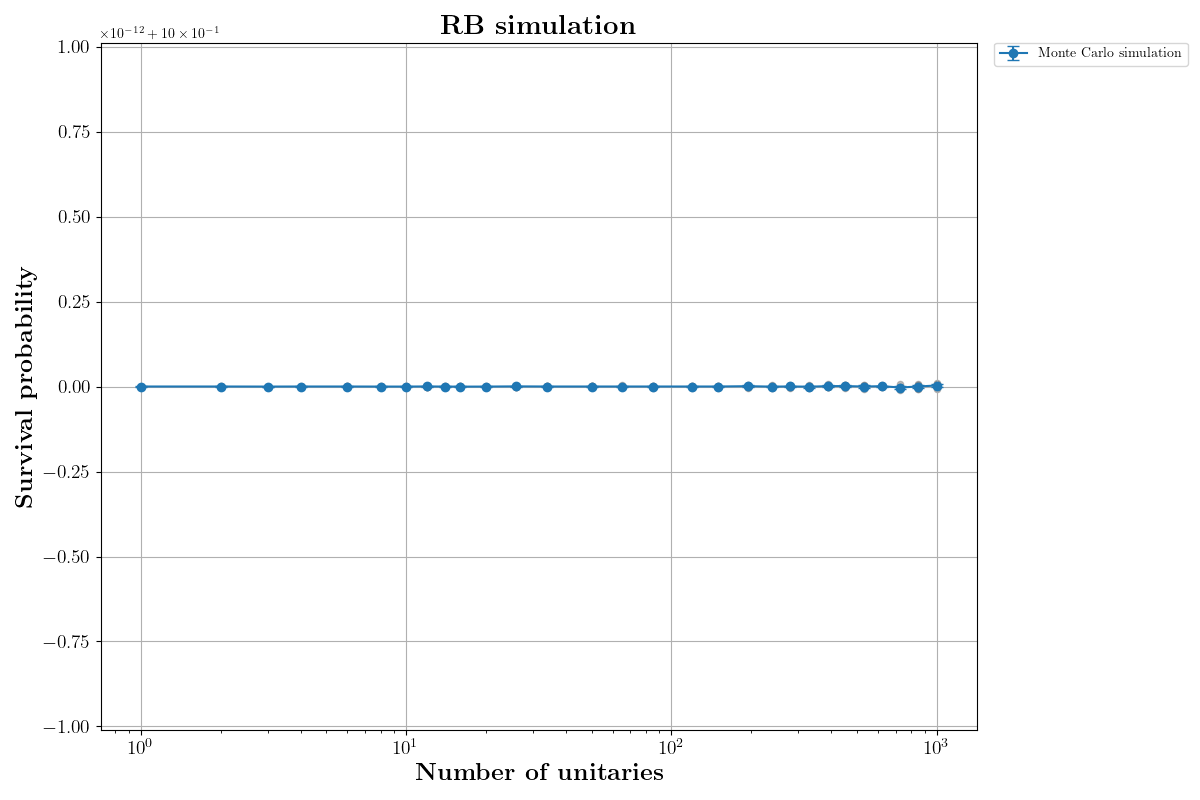

In [80]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True

rb_simulation_result = simulate_RB(
    couplings_list,
    corrected_pulse_times_list,
    angle_train_list,
    phase_train_list,
    pi_time_refs_list,
    n_units_list,
    num_shots=1,
)

simulated_n_units = np.asarray(rb_simulation_result["n_units_list"], dtype=float)
simulated_mean_survival = rb_simulation_result["mean_survival_list"]
simulated_std_survival = rb_simulation_result["std_survival_list"]

fig, ax = plt.subplots(figsize=(12, 8))

for n_units in simulated_n_units:
    sequence_mean_survival = rb_simulation_result["results_by_n_units"][int(n_units)]["sequence_mean_survival"]
    ax.scatter(
        np.full(len(sequence_mean_survival), n_units),
        sequence_mean_survival,
        color='gray',
        alpha=0.5,
        s=20,
    )

ax.errorbar(
    simulated_n_units,
    simulated_mean_survival,
    yerr=simulated_std_survival,
    fmt='o-',
    color='tab:blue',
    capsize=4,
    label='Monte Carlo simulation',
)

ax.set_xscale('log')
plt.xlabel(r'\boldmath$\textbf{Number\ of\ unitaries}$', fontsize=18)
plt.ylabel(r'\boldmath$\textbf{Survival\ probability}$', fontsize=18)
plt.title(r'\textbf{RB simulation}', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.grid()
ax.legend(bbox_to_anchor=(1.02, 1.0), loc='upper left', borderaxespad=0.0)
fig.subplots_adjust(right=0.75)
plt.tight_layout()
plt.show()
